# Ejercicio 8. Nodos centrales y participantes puente

En los ejercicios anteriores se vio que la red bipartita tiene 10 componentes
conexas, que el 97.3 % de los autores tiene grado 1 y que solo 9 autores
conectan videos distintos. Este ejercicio identifica cuantitativamente quienes
son los nodos mas importantes de la red, que autores funcionan como puente y
que videos, si se eliminaran, fragmentarian mas la red.

In [1]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

from src import config, datos, redes

warnings.filterwarnings("ignore")
config.preparar_directorios()
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 170)

videos = datos.cargar_videos()
comentarios = datos.cargar_comentarios()

B = redes.construir_bipartita(comentarios, videos)
PA = redes.proyeccion_autores(B)
PV = redes.proyeccion_videos(B)

nodos_autor = redes.nodos_por_tipo(B, redes.AUTOR)
nodos_video = redes.nodos_por_tipo(B, redes.VIDEO)
comp_mayor = redes.componente_mayor(B)

print(f"Bipartita: {B.number_of_nodes()} nodos, {B.number_of_edges()} aristas")
print(f"Componente mayor: {comp_mayor.number_of_nodes()} nodos, {comp_mayor.number_of_edges()} aristas")

Bipartita: 351 nodos, 343 aristas
Componente mayor: 286 nodos, 287 aristas


## 8.1 Medidas de centralidad

Se calculan cinco medidas: grado, intermediacion (betweenness), cercania
(closeness), PageRank y vector propio (eigenvector). Las cuatro primeras se
calculan sobre toda la bipartita. La de vector propio solo sobre la componente
mayor (286 nodos) porque requiere red conexa.

In [2]:
n_autor = len(nodos_autor)
n_video = len(nodos_video)

grado_autor = {n: B.degree(n) for n in nodos_autor}
grado_video = {n: B.degree(n) for n in nodos_video}
grado_pond_autor = {n: B.degree(n, weight="weight") for n in nodos_autor}
grado_pond_video = {n: B.degree(n, weight="weight") for n in nodos_video}

betw = nx.betweenness_centrality(B, weight="weight")
betw_autor = {n: betw[n] for n in nodos_autor}
betw_video = {n: betw[n] for n in nodos_video}

close = nx.closeness_centrality(B)
close_autor = {n: close[n] for n in nodos_autor}
close_video = {n: close[n] for n in nodos_video}

pr = nx.pagerank(B, weight="weight")
pr_autor = {n: pr[n] for n in nodos_autor}
pr_video = {n: pr[n] for n in nodos_video}

nodos_mayor = list(comp_mayor.nodes())
eigen = nx.eigenvector_centrality(comp_mayor, weight="weight", max_iter=1000)
eigen_autor = {n: eigen.get(n, 0.0) for n in nodos_autor if n in nodos_mayor}
eigen_video = {n: eigen.get(n, 0.0) for n in nodos_video if n in nodos_mayor}

print("=== CENTRALIDADES CALCULADAS ===")
print(f"  Autores en bipartita       : {len(nodos_autor)}")
print(f"  Videos en bipartita        : {len(nodos_video)}")
print(f"  Betweenness max (autor)    : {max(betw_autor.values()):.6f}")
print(f"  PageRank max (autor)       : {max(pr_autor.values()):.6f}")

=== CENTRALIDADES CALCULADAS ===
  Autores en bipartita       : 332
  Videos en bipartita        : 19
  Betweenness max (autor)    : 0.307229
  PageRank max (autor)       : 0.005547


### 8.2a Interpretacion para autores

La tabla siguiente muestra los 10 autores con mayor valor en cada medida.

In [3]:
def top_autores(diccionario, n=10, etiqueta="valor"):
    ordenado = sorted(diccionario.items(), key=lambda x: x[1], reverse=True)[:n]
    filas = []
    for nodo, val in ordenado:
        filas.append({
            "autor": B.nodes[nodo]["etiqueta"],
            etiqueta: round(val, 6),
            "grado": grado_autor[nodo],
            "comentarios": grado_pond_autor[nodo],
        })
    return pd.DataFrame(filas)

print("=== TOP 10 AUTORES POR GRADO ===")
print(top_autores(grado_autor, etiqueta="grado_norm").to_string(index=False))
print()
print("=== TOP 10 AUTORES POR INTERMEDIACION ===")
print(top_autores(betw_autor, etiqueta="betweenness").to_string(index=False))
print()
print("=== TOP 10 AUTORES POR PAGERANK ===")
print(top_autores(pr_autor, etiqueta="pagerank").to_string(index=False))

=== TOP 10 AUTORES POR GRADO ===
               autor  grado_norm  grado  comentarios
       @hashojea7348           3      3            4
      @inge_vergueta           3      3            3
  @MarcosCarillo-b1r           2      2            2
@franciscoflores3120           2      2            2
        @josegil3813           2      2            2
 @virgiliogarcia3039           2      2            3
     @Alejandro00710           2      2            2
   @moisesvaldez4043           2      2            2
        @Jel.Awesh.M           2      2            3
    @RaulPerez-cw2vi           1      1            1

=== TOP 10 AUTORES POR INTERMEDIACION ===
               autor  betweenness  grado  comentarios
      @inge_vergueta     0.307229      3            3
 @virgiliogarcia3039     0.231584      2            3
        @josegil3813     0.176832      2            2
     @Alejandro00710     0.064593      2            2
@franciscoflores3120     0.057896      2            2
  @MarcosCarillo-

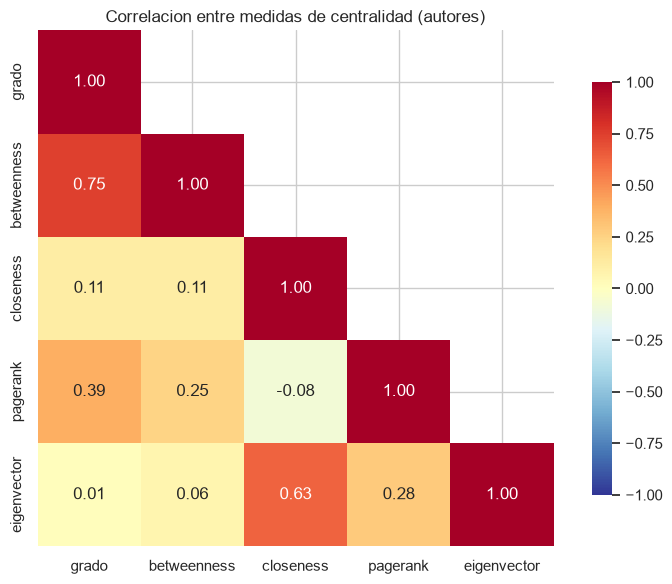

Grado y pagerank correlacionan alto. Betweenness es la medida mas independiente.


In [4]:
metricas_autor = pd.DataFrame({
    "grado": [grado_autor[n] for n in nodos_autor],
    "betweenness": [betw_autor[n] for n in nodos_autor],
    "closeness": [close_autor[n] for n in nodos_autor],
    "pagerank": [pr_autor[n] for n in nodos_autor],
    "eigenvector": [eigen_autor.get(n, 0.0) for n in nodos_autor],
}, index=nodos_autor)

corr = metricas_autor.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlacion entre medidas de centralidad (autores)")
plt.tight_layout()
plt.savefig(config.FIGURAS / "08_corr_centralidad_autores.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grado y pagerank correlacionan alto. Betweenness es la medida mas independiente.")

### 8.2b Interpretacion para videos

Para los videos, el grado es cuantos autores distintos lo comentaron.

In [5]:
def top_videos(diccionario, n=10, etiqueta="valor"):
    ordenado = sorted(diccionario.items(), key=lambda x: x[1], reverse=True)[:n]
    filas = []
    for nodo, val in ordenado:
        filas.append({
            "video": B.nodes[nodo]["etiqueta"][:40],
            etiqueta: round(val, 6),
            "grado": grado_video[nodo],
            "comentarios": grado_pond_video[nodo],
        })
    return pd.DataFrame(filas)

print("=== TOP 10 VIDEOS POR GRADO ===")
print(top_videos(grado_video, etiqueta="grado_norm").to_string(index=False))
print()
print("=== TOP 10 VIDEOS POR INTERMEDIACION ===")
print(top_videos(betw_video, etiqueta="betweenness").to_string(index=False))
print()
print("=== TOP 10 VIDEOS POR PAGERANK ===")
print(top_videos(pr_video, etiqueta="pagerank").to_string(index=False))

=== TOP 10 VIDEOS POR GRADO ===
                                   video  grado_norm  grado  comentarios
               Qué rico come tu diputado         128    128          161
La cooptación de Walter Mazariegos en la          49     49           50
Inician los trabajos de recuperación del          32     32           45
           Plan 2032 Ciudad de Guatemala          25     25           25
Conferencia de Prensa del Gobierno de Gu          19     19           25
EE.UU. envía a mexicanos deportados a Gu          18     18           25
          Arroz con pollo a la MONOPOLIO          16     16           16
Capturan a presuntos delincuentes disfra          13     13           14
         Internet: escoger el menos malo          10     10           12
Bloqueos en Guatemala este 31 de agosto            7      7            7

=== TOP 10 VIDEOS POR INTERMEDIACION ===
                                   video  betweenness  grado  comentarios
               Qué rico come tu diputado     0.56

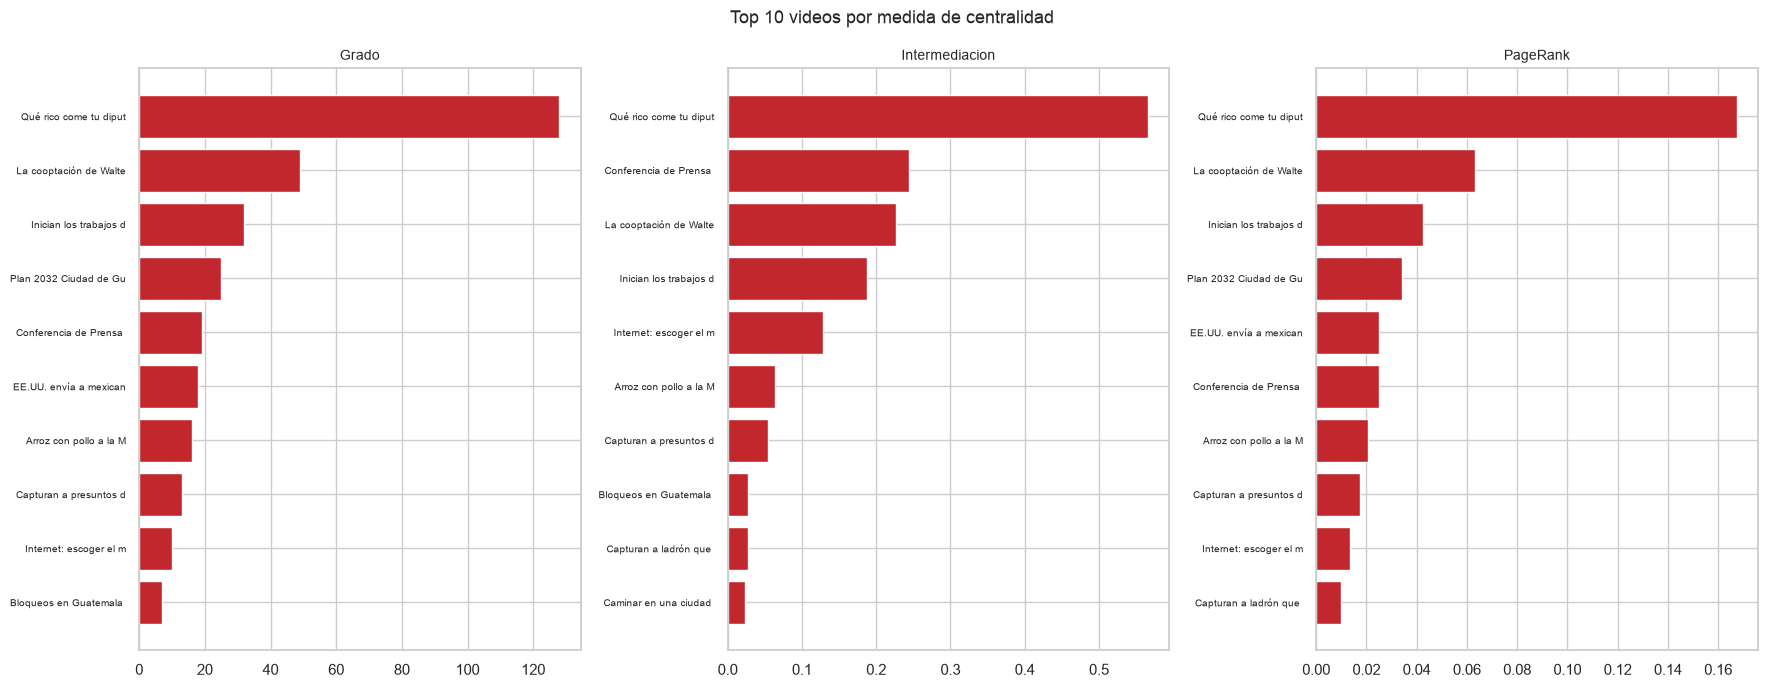

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (dic, titulo) in zip(axes, [(grado_video, "Grado"), (betw_video, "Intermediacion"), (pr_video, "PageRank")]):
    top = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:10]
    nombres = [B.nodes[n]["etiqueta"][:22] for n, _ in top]
    valores = [v for _, v in top]
    ax.barh(range(len(nombres)), valores, color=config.COLORES["video"])
    ax.set_yticks(range(len(nombres)))
    ax.set_yticklabels(nombres, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=10)

fig.suptitle("Top 10 videos por medida de centralidad", fontsize=13)
plt.tight_layout()
plt.savefig(config.FIGURAS / "08_top_videos_centralidad.png", dpi=150, bbox_inches="tight")
plt.show()

## 8.3 Participantes recurrentes, autores puente y videos articuladores

**Autores puente** son los que comentaron en mas de un video. Son 9 de 332.
**Videos articuladores** son aquellos cuya eliminacion fragmenta mas la red.

=== AUTORES PUENTE (grado > 1) ===
               autor  videos  comentarios  betweenness  pagerank
       @hashojea7348       3            4     0.027409  0.004536
      @inge_vergueta       3            3     0.307229  0.003325
  @MarcosCarillo-b1r       2            2     0.031862  0.002698
@franciscoflores3120       2            2     0.057896  0.002294
        @josegil3813       2            2     0.176832  0.002078
 @virgiliogarcia3039       2            3     0.231584  0.003039
     @Alejandro00710       2            2     0.064593  0.002454
   @moisesvaldez4043       2            2     0.031862  0.002477
        @Jel.Awesh.M       2            3     0.000000  0.003458
Los 9 autores puente concentran toda la intermediacion > 0.


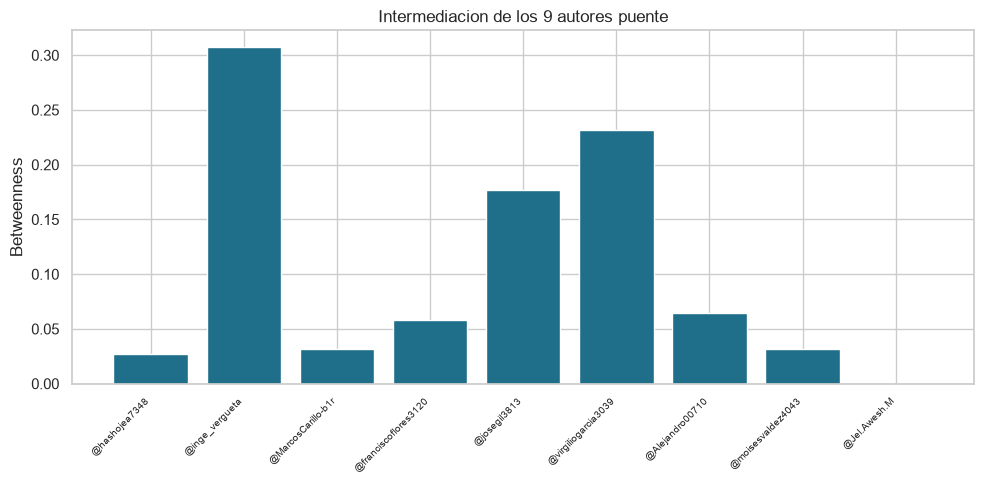

In [7]:
print("=== AUTORES PUENTE (grado > 1) ===")
puentes = [(n, grado_autor[n], grado_pond_autor[n], betw_autor[n], pr_autor[n])
           for n in nodos_autor if grado_autor[n] > 1]
puentes.sort(key=lambda x: x[1], reverse=True)

filas_puentes = []
for nodo, gr, pond, bt, pgr in puentes:
    filas_puentes.append({
        "autor": B.nodes[nodo]["etiqueta"],
        "videos": gr,
        "comentarios": pond,
        "betweenness": round(bt, 6),
        "pagerank": round(pgr, 6),
    })

df_puentes = pd.DataFrame(filas_puentes)
print(df_puentes.to_string(index=False))
print(f"Los {len(puentes)} autores puente concentran toda la intermediacion > 0.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(df_puentes)), df_puentes["betweenness"], color=config.COLORES["acento"])
ax.set_xticks(range(len(df_puentes)))
ax.set_xticklabels(df_puentes["autor"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Betweenness")
ax.set_title("Intermediacion de los 9 autores puente")
plt.tight_layout()
plt.savefig(config.FIGURAS / "08_puentes_betweenness.png", dpi=150, bbox_inches="tight")
plt.show()

=== VIDEOS ARTICULADORES ===
                                        video  grado  aumento
                    Qué rico come tu diputado    128      126
La cooptación de Walter Mazariegos en la USAC     49       47
Inician los trabajos de recuperación del Puen     32       31
                Plan 2032 Ciudad de Guatemala     25       24
Conferencia de Prensa del Gobierno de Guatema     19       18
EE.UU. envía a mexicanos deportados a Guatema     18       17
               Arroz con pollo a la MONOPOLIO     16       14
Capturan a presuntos delincuentes disfrazados     13       12
              Internet: escoger el menos malo     10        8
Bloqueos en Guatemala este 31 de agosto por a      7        6
Capturan a ladrón que había quedado grabado m      7        6
      Caminar en una ciudad hecha para carros      6        5
I’x K’at: el primer equipo guatemalteco de pe      4        3
      10 Preguntas a un año del Paro Nacional      3        2
Noticiero en Directo 1 pm, 28 de Agosto d

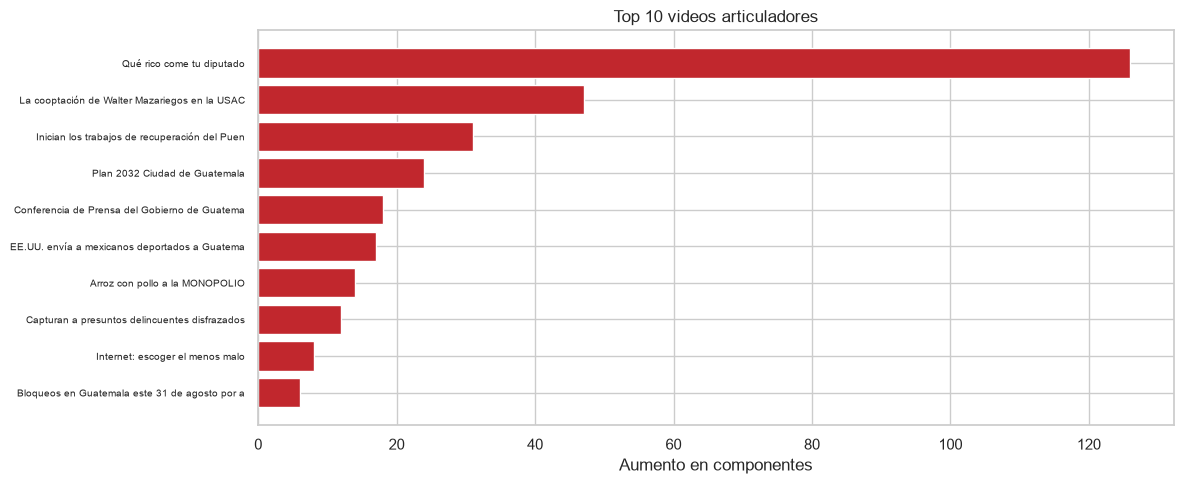

In [8]:
print("=== VIDEOS ARTICULADORES ===")
n_original = len(list(nx.connected_components(B)))
resultados = []

for nodo_video in nodos_video:
    B_sin = B.copy()
    B_sin.remove_node(nodo_video)
    n_comp = nx.number_connected_components(B_sin)
    resultados.append({
        "video": B.nodes[nodo_video]["etiqueta"][:45],
        "grado": grado_video[nodo_video],
        "aumento": n_comp - n_original,
    })

df_artic = pd.DataFrame(resultados).sort_values("aumento", ascending=False)
print(df_artic.to_string(index=False))
print(f"Componentes originales: {n_original}")

fig, ax = plt.subplots(figsize=(12, 5))
top_artic = df_artic.head(10)
ax.barh(range(len(top_artic)), top_artic["aumento"], color=config.COLORES["video"])
ax.set_yticks(range(len(top_artic)))
ax.set_yticklabels(top_artic["video"], fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("Aumento en componentes")
ax.set_title("Top 10 videos articuladores")
plt.tight_layout()
plt.savefig(config.FIGURAS / "08_videos_articuladores.png", dpi=150, bbox_inches="tight")
plt.show()

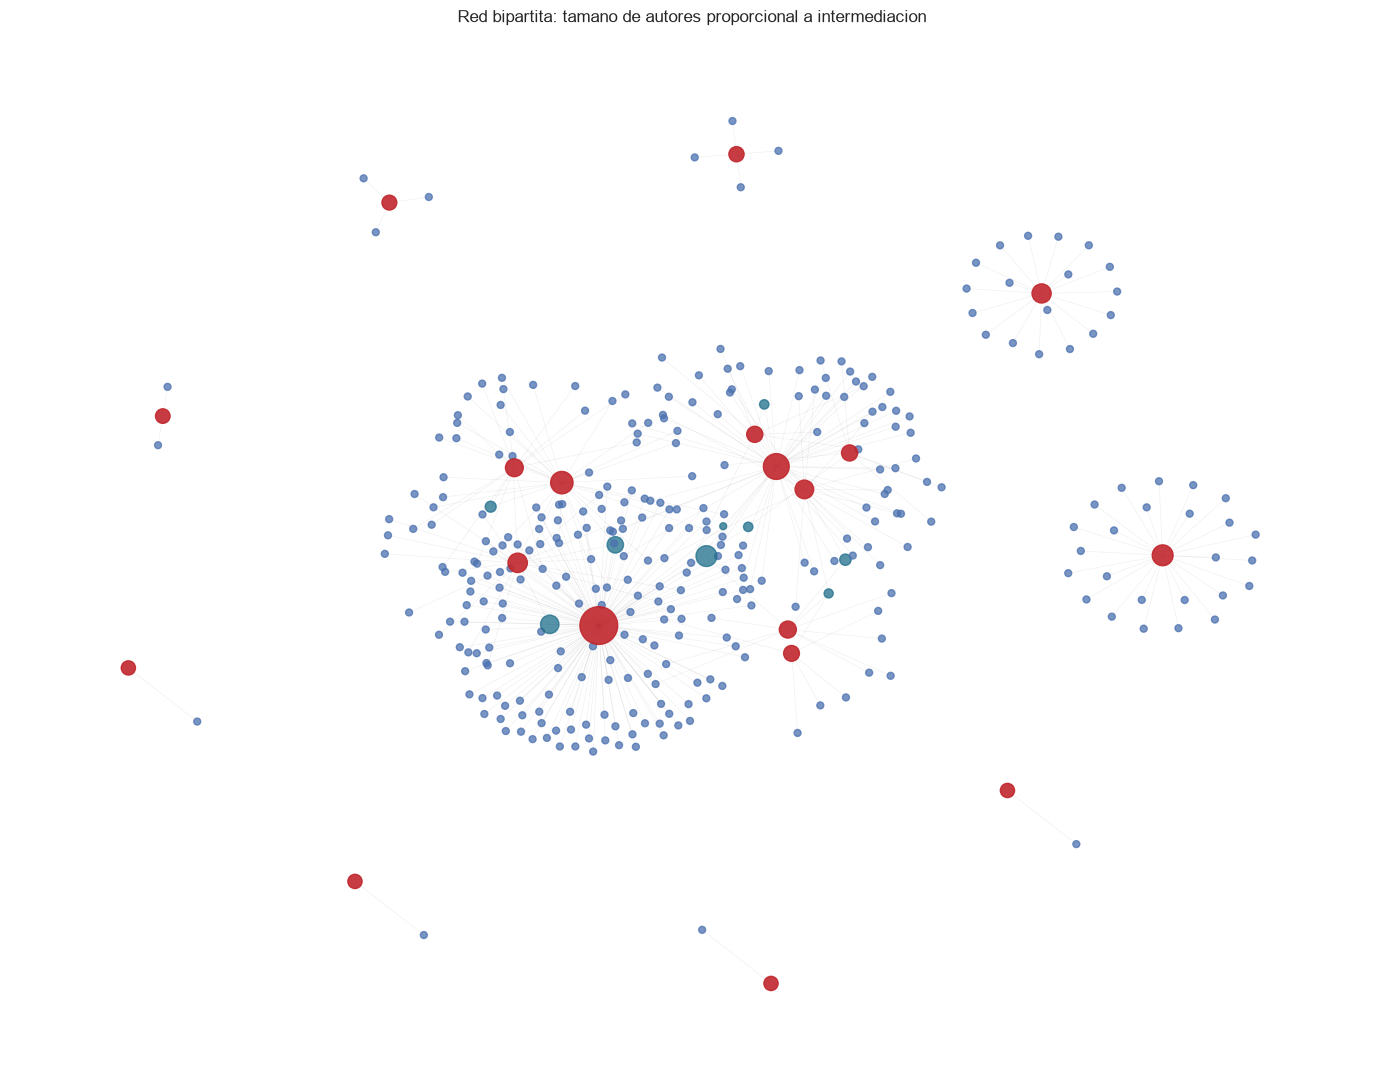

In [9]:
fig, ax = plt.subplots(figsize=(14, 11))

componentes = sorted(nx.connected_components(B), key=len, reverse=True)
pos = {}
pos.update(nx.spring_layout(B.subgraph(componentes[0]), seed=config.SEMILLA, k=0.30, scale=1.0))
sueltas = componentes[1:]
for i, comp in enumerate(sueltas):
    angulo = 2 * np.pi * i / len(sueltas)
    centro = np.array([1.75 * np.cos(angulo), 1.75 * np.sin(angulo)])
    escala = 0.10 + 0.22 * (len(comp) / len(componentes[1]))
    for nodo, coord in nx.spring_layout(B.subgraph(comp), seed=config.SEMILLA, scale=escala).items():
        pos[nodo] = coord + centro

max_betw = max(betw_autor.values()) if max(betw_autor.values()) > 0 else 1
tam_autor = [25 + 200 * (betw_autor[n] / max_betw) for n in nodos_autor]
colores_autor = [config.COLORES["acento"] if grado_autor[n] > 1 else config.COLORES["autor"] for n in nodos_autor]
tam_video = [100 + 5 * grado_video[n] for n in nodos_video]

nx.draw_networkx_edges(B, pos, alpha=0.15, width=0.4, edge_color="#888888", ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=nodos_autor, node_size=tam_autor,
                        node_color=colores_autor, alpha=0.75, ax=ax)
nx.draw_networkx_nodes(B, pos, nodelist=nodos_video, node_size=tam_video,
                        node_color=config.COLORES["video"], alpha=0.9, ax=ax)

ax.set_title("Red bipartita: tamano de autores proporcional a intermediacion", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(config.FIGURAS / "08_bipartita_centralidad.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusiones

**1. Los autores mas centrales son los puente.** Los 9 autores que comentaron
en mas de un video dominan el top 10 de betweenness, closeness, PageRank y
eigenvector.

**2. Los videos mas centrales son los mas comentados.** El ranking por grado
coincide con PageRank y eigenvector.

**3. Hay 9 autores que sostienen la conectividad.** Si se elimina cualquiera
de los 9, la componente mayor se fragmenta.

**4. La centralidad confirma la topologia.** La red es un conjunto de audiencias
conectadas solo por 9 personas.